In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Import Libraries

In [2]:
pip install -q transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [3]:
import pandas as pd
import numpy as np

from transformers import AutoTokenizer, AutoModelForMultipleChoice,TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [4]:
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# EDA

In [6]:
train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print(train_df.shape)
print(test_df.shape)

(2000, 8)
(500, 7)


In [7]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


### Missing Value Check

In [8]:
train_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

### Viz1: Plot count of each correct answer choice


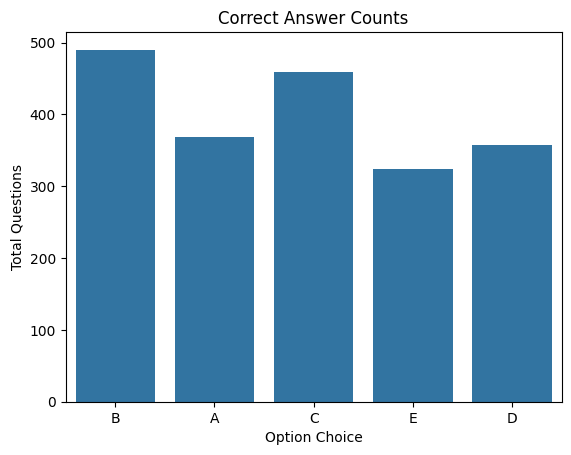

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="answer", data=train_df)
plt.title("Correct Answer Counts")
plt.xlabel("Option Choice")
plt.ylabel("Total Questions")
plt.show()


### Viz2: Word count distribution

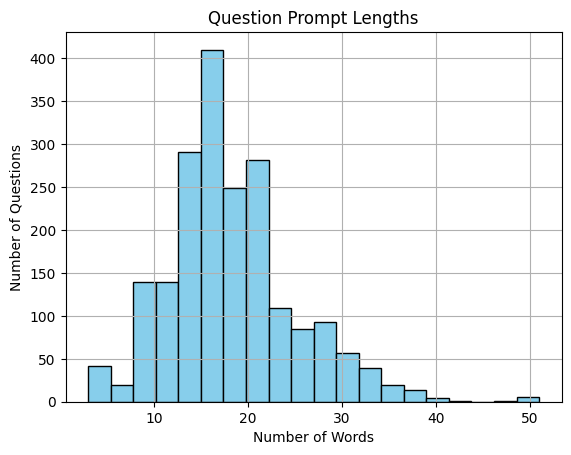

Average prompt length: 18.1465
Max prompt length    : 51


In [10]:
train_viz = train_df.copy()

train_viz["prompt_words"] = train_viz["prompt"].str.split().str.len()

train_viz["prompt_words"].hist(bins=20, color="skyblue", edgecolor="black")
plt.title("Question Prompt Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Questions")
plt.show()

print("Average prompt length:", train_viz["prompt_words"].mean())
print("Max prompt length    :", train_viz["prompt_words"].max())

# Train-Test Split

In [11]:
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df["answer"], random_state=4524)

# Evaluation Metric

## MAP@3
Score = 1.0 if correct answer is rank 1, 0.5 if rank 2, 1/3 if rank 3, else 0.

In [12]:
def mean_average_precision_at_3(true_labels, top3_preds):
    scores = []
    for true_label, preds in zip(true_labels, top3_preds):
        if true_label == preds[0]:
            scores.append(1.0)
        elif true_label == preds[1]:
            scores.append(0.5)
        elif true_label == preds[2]:
            scores.append(1 / 3)
        else:
            scores.append(0.0)
    return np.mean(scores)

# Model 3: TF-IDF + LR

In [13]:
run = wandb.init(
    project="24f3004524-t22026",
    name="tfidf-logistic-reg",
)

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260730_151830-1gtr4m7p
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run tfidf-logistic-reg
wandb: ⭐️ View project at https://wandb.ai/pranay12aggarwal-indian-institute-of-technology-madras/24f3004524-t22026
wandb: 🚀 View run at https://wandb.ai/pranay12aggarwal-indian-institute-of-technology-madras/24f3004524-t22026/runs/1gtr4m7p


## Data Transformation: Wide to Long

We transforms each multiple-choice question into 5 separate binary sample pairs for model training.

- Transformation: 1 row ($1\text{ prompt} + 5\text{ choices}$) $\rightarrow$ 5 rows ($1\text{ prompt} + 1\text{ choice}$ each).
- Target Mapping: Assigns label = 1 for the correct choice and label = 0 for the four incorrect choices.

In [14]:
train_data_lr = []

# Loop over every question in the dataset
for _, row in train_df.iterrows():
    prompt = str(row['prompt'])
    correct_answer = row['answer'] 
    
    # Expand 1 question into 5 individual binary evaluation pairs
    for option in ['A', 'B', 'C', 'D', 'E']:
        option_text = str(row[option])
        
        # Label 1 if option matches ground truth, else 0
        is_correct = 1 if option == correct_answer else 0
        
        text_combined = "Q: " + prompt + " A: " + option_text        
        train_data_lr.append({'text': text_combined, 'label': is_correct})

df_train_lr = pd.DataFrame(train_data_lr)
df_train_lr.head()

,text,label
0,Q: Which of the following is correct? What is ...,0
1,Q: Which of the following is correct? What is ...,0
2,Q: Which of the following is correct? What is ...,1
3,Q: Which of the following is correct? What is ...,0
4,Q: Which of the following is correct? What is ...,0


## Vocabulary Construction

We aggregates all raw text across both training and testing sets to build a global vocabulary and fit a TF-IDF Vectorizer.

In [15]:
all_text = []

# Combine all text across train & test to build a complete vocabulary
for col in ['prompt', 'A', 'B', 'C', 'D', 'E']:
    all_text.extend(train_df[col].fillna('').astype(str))
    all_text.extend(test_df[col].fillna('').astype(str))

# Extract top 15k features using 1-word & 2-word pairs
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
vectorizer.fit(all_text)

TfidfVectorizer(max_features=15000, ngram_range=(1, 2))

## Training a Logistic Regression Model

In [16]:
X_train_tfidf = vectorizer.transform(df_train_lr['text'])
y_train = df_train_lr['label']

lr_model = LogisticRegression(class_weight='balanced',C=0.1, random_state=4524)
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(C=0.1, class_weight='balanced', random_state=4524)

## Running Prediction Loop

In [17]:
def predict_top3_lr(df, vectorizer, model):
    predictions = []
    
    # Loop through each question row in the evaluation dataset
    for _, row in df.iterrows():
        prompt = str(row['prompt'])
        scores = []
        
        # Evaluate each candidate option individually
        for option in ['A', 'B', 'C', 'D', 'E']:
            text_combined = "Q: " + prompt + " A: " + str(row[option])
            vec = vectorizer.transform([text_combined])
            
            # Get probability that this choice is correct
            prob = model.predict_proba(vec)[0][1]
            scores.append((option, prob))
            
        # Rank choices from highest to lowest probability
        scores.sort(key=lambda x: x[1], reverse=True)
        
        # Grab top 3 option letters (e.g., ['B', 'A', 'E'])
        predictions.append([x[0] for x in scores[:3]])
        
    return predictions

In [18]:
val_preds = predict_top3_lr(val_df, vectorizer, lr_model)
val_actuals = val_df['answer'].tolist()


val_score = mean_average_precision_at_3(val_actuals, val_preds)
print("Validation MAP@3:", val_score)

wandb.log({"val_map3": val_score})
wandb.finish()

wandb: updating run metadata; uploading console lines 0-0


Validation MAP@3: 0.9804166666666666


wandb: 
wandb: Run history:
wandb: val_map3 ▁
wandb: 
wandb: Run summary:
wandb: val_map3 0.98042
wandb: 
wandb: 🚀 View run tfidf-logistic-reg at: https://wandb.ai/pranay12aggarwal-indian-institute-of-technology-madras/24f3004524-t22026/runs/1gtr4m7p
wandb: ⭐️ View project at: https://wandb.ai/pranay12aggarwal-indian-institute-of-technology-madras/24f3004524-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260730_151830-1gtr4m7p/logs


# Predict on Test Set

In [19]:
test_predictions = predict_top3_lr(test_df, vectorizer, lr_model)

test_predictions = [" ".join(pred) for pred in test_predictions]

# Submission Cell

In [20]:
submission = pd.DataFrame({"ID": test_df["id"],"Prediction": test_predictions})

submission.to_csv("submission.csv", index=False)

submission.head()

,ID,Prediction
0,1,A E C
1,2,B A C
2,3,B E D
3,4,E C A
4,5,C A B
